In [1]:
import json
import pickle
from pathlib import Path
from collections import Counter

import pandas as pd
from tqdm.notebook import tqdm

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [2]:
nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /Users/Thorvald-The-
[nltk_data]     Great/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/Thorvald-The-
[nltk_data]     Great/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
INPUT_FILE = "995,000_rows.csv"
OUTPUT_DIR = Path("processed_chunks_paquet")
OUTPUT_DIR.mkdir(exist_ok=True)

CHUNK_SIZE = 10000
TEXT_COL = "content"
LABEL_COL = "type"
DOMAIN_COL = "domain"
URL_COL = "url"
DATE_COL = "scraped_at"

In [4]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def tokenize_text(text):
    text = str(text).lower()
    return word_tokenize(text)

def clean_tokens(tokens):
    # Keep alphabetic tokens only, remove stopwords
    return [t for t in tokens if t.isalpha() and t not in stop_words]

def stem_tokens(tokens):
    return [stemmer.stem(t) for t in tokens]

In [5]:
stats = {
    "n_rows": 0,
    "n_missing_content": 0,
    "total_tokens_before": 0,
    "total_tokens_after_stopwords": 0,
    "unique_tokens_before": set(),
    "unique_tokens_after_stopwords": set(),
    "unique_tokens_after_stemming": set(),
    "top_words_before": Counter(),
    "top_words_after_stopwords": Counter(),
    "top_words_after_stemming": Counter(),
}

In [6]:
chunk_files = []

reader = pd.read_csv(INPUT_FILE, chunksize=CHUNK_SIZE)

for i, chunk in enumerate(tqdm(reader, desc="Processing chunks", total=995000//10000)):
    # Keep columns if present
    #content handling
    missing_mask = chunk[TEXT_COL].isna()
    stats["n_missing_content"] += int(missing_mask.sum())
    chunk = chunk.dropna(subset=[TEXT_COL]).copy()

    # Force text type
    chunk[TEXT_COL] = chunk[TEXT_COL].astype(str)

    # Temporary tokenization
    raw_tokens = chunk[TEXT_COL].apply(tokenize_text)

    # Update pre-cleaning stats from raw tokens
    for toks in raw_tokens:
        stats["total_tokens_before"] += len(toks)
        stats["unique_tokens_before"].update(toks)
        stats["top_words_before"].update(toks)

    # Clean tokens
    chunk["tokens_clean"] = raw_tokens.apply(clean_tokens)

    # Update post-stopword stats
    for toks in chunk["tokens_clean"]:
        stats["total_tokens_after_stopwords"] += len(toks)
        stats["unique_tokens_after_stopwords"].update(toks)
        stats["top_words_after_stopwords"].update(toks)

    # Stemmed tokens
    chunk["tokens_stemmed"] = chunk["tokens_clean"].apply(stem_tokens)

    # Update stemming stats
    for toks in chunk["tokens_stemmed"]:
        stats["unique_tokens_after_stemming"].update(toks)
        stats["top_words_after_stemming"].update(toks)

    # Build clean text for later modelling
    chunk["clean_text"] = chunk["tokens_stemmed"].apply(lambda x: " ".join(x))

    # Count processed rows
    stats["n_rows"] += len(chunk)

    # Keep all original columns except the raw text
    exclude = {TEXT_COL, "tokens_clean", "clean_text"}
    cols_to_save = [col for col in chunk.columns if col not in exclude]

    chunk_out = chunk[cols_to_save].copy()

    out_file = OUTPUT_DIR / f"chunk_{i:03d}.parquet"
    chunk_out.to_parquet(out_file)
    chunk_files.append(str(out_file))

    # Free memory
    del chunk
    del chunk_out
    del raw_tokens

Processing chunks:   0%|          | 0/99 [00:00<?, ?it/s]

rows processed: 994988
vocabulary before: 2680387
vocabulary after stopwords: 1206288
vocabulary after stemming: 1049849
Saved chunks: 100


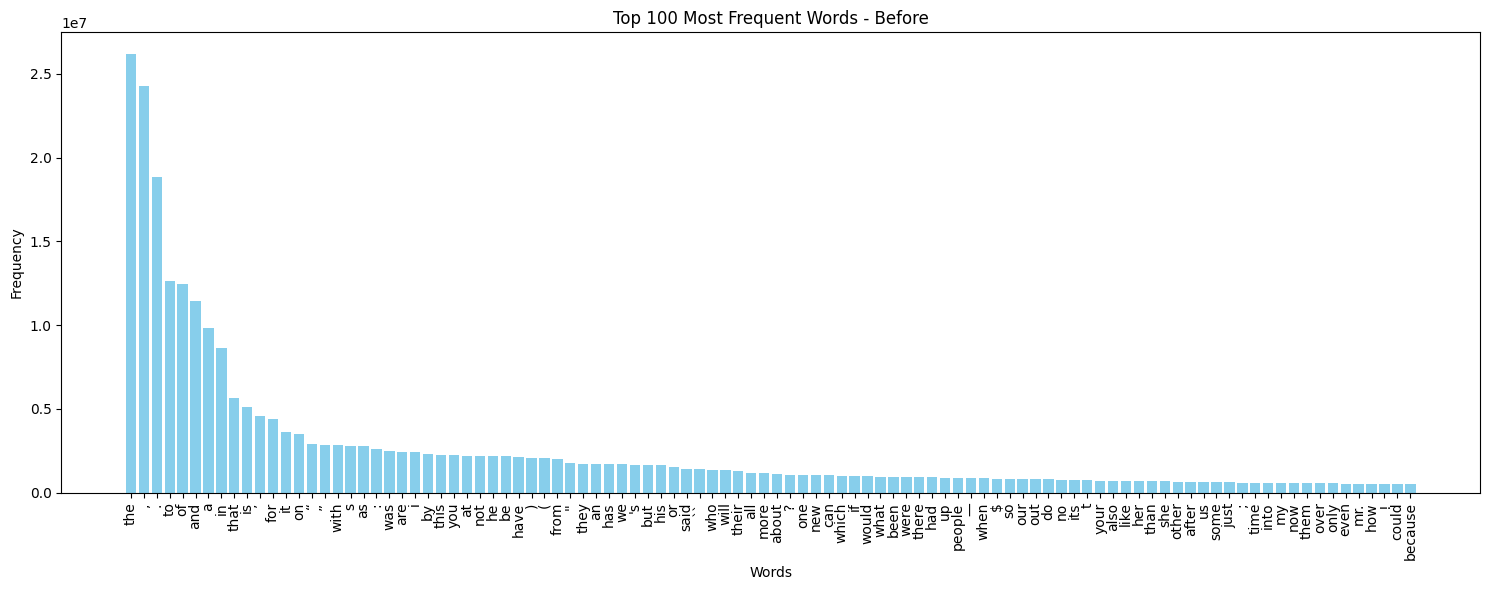

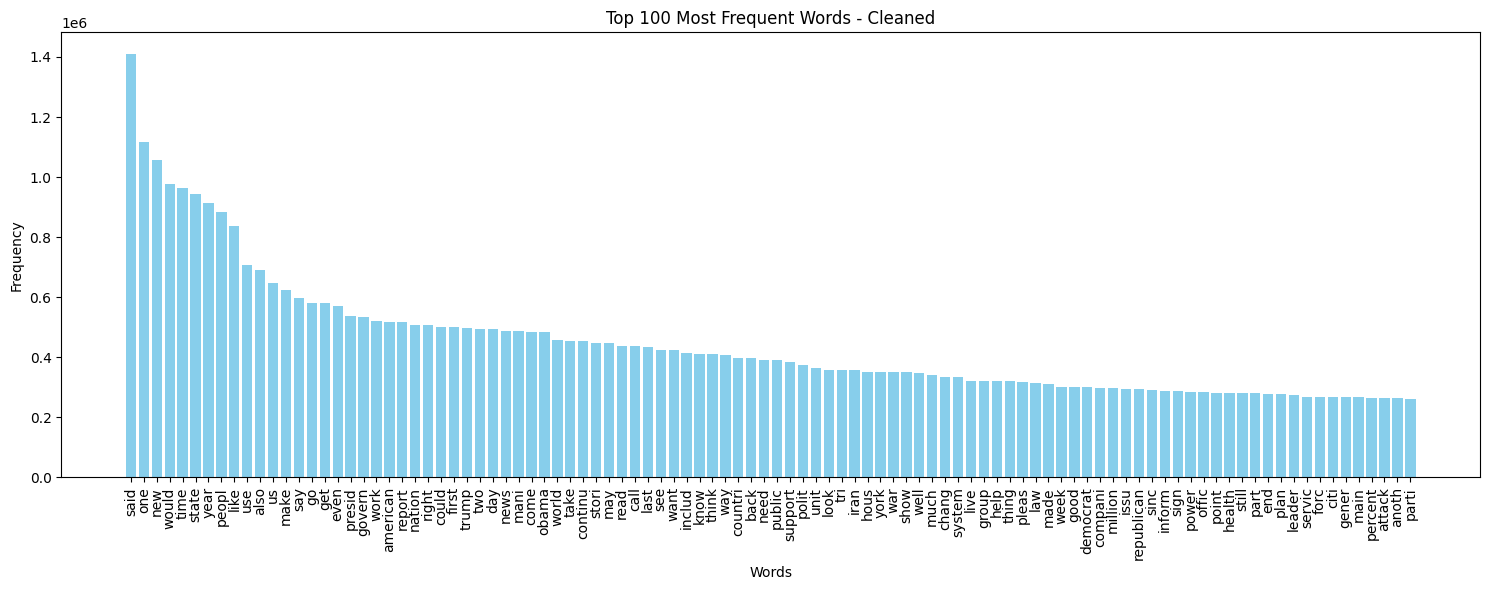

In [7]:
import matplotlib.pyplot as plt

summary = {
    "n_rows": stats["n_rows"],
    "n_missing_content": stats["n_missing_content"],
    "total_tokens_before": stats["total_tokens_before"],
    "total_tokens_after_stopwords": stats["total_tokens_after_stopwords"],
    "vocab_size_before": len(stats["unique_tokens_before"]),
    "vocab_size_after_stopwords": len(stats["unique_tokens_after_stopwords"]),
    "vocab_size_after_stemming": len(stats["unique_tokens_after_stemming"]),
    "reduction_rate_stopwords": 1 - (
        len(stats["unique_tokens_after_stopwords"]) / len(stats["unique_tokens_before"])
        if len(stats["unique_tokens_before"]) > 0 else 1
    ),
    "reduction_rate_stemming": 1 - (
        len(stats["unique_tokens_after_stemming"]) / len(stats["unique_tokens_after_stopwords"])
        if len(stats["unique_tokens_after_stopwords"]) > 0 else 1
    ),
    "top_100_before": stats["top_words_before"].most_common(100),
    "top_100_after_stopwords": stats["top_words_after_stopwords"].most_common(100),
    "top_100_after_stemming": stats["top_words_after_stemming"].most_common(100),
    "chunk_files": chunk_files,
}

with open("task2_summary.pkl", "wb") as f:
    pickle.dump(summary, f)

with open("task2_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("rows processed:", summary["n_rows"])
print("vocabulary before:", summary["vocab_size_before"])
print("vocabulary after stopwords:", summary["vocab_size_after_stopwords"])
print("vocabulary after stemming:", summary["vocab_size_after_stemming"])
print("Saved chunks:", len(chunk_files))

words_default = [w for w, c in summary["top_100_before"]]
counts_default = [c for w, c in summary["top_100_before"]]

words_cleaned = [w for w, c in summary["top_100_after_stemming"]]
counts_cleaned = [c for w, c in summary["top_100_after_stemming"]]



# Plot the bar chart of before
plt.figure(figsize=(15, 6))  
plt.bar( words_default, counts_default, color='skyblue')
plt.xticks(rotation=90)      
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 100 Most Frequent Words - Before')
plt.tight_layout()
plt.show()

# Plot the bar chart of after
plt.figure(figsize=(15, 6))  
plt.bar(words_cleaned, counts_cleaned, color='skyblue')
plt.xticks(rotation=90)      
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 100 Most Frequent Words - Cleaned')
plt.tight_layout()
plt.show()


In [11]:
#Tjek en chunk
df1 = pd.read_parquet("processed_chunks_paquet/chunk_000.parquet")
print(df1.head())

   Unnamed: 0         id               domain        type  \
0         732  7444726.0   nationalreview.com   political   
1        1348  6213642.0    beforeitsnews.com        fake   
2        7119  3867639.0     dailycurrant.com      satire   
3        1518  9560791.0          nytimes.com    reliable   
4        9345  2059625.0  infiniteunknown.net  conspiracy   

                                                 url  \
0  http://www.nationalreview.com/node/152734/%E2%...   
1  http://beforeitsnews.com/economy/2012/06/the-c...   
2  http://dailycurrant.com/2016/01/18/man-awoken-...   
3  https://query.nytimes.com/gst/fullpage.html?re...   
4  http://www.infiniteunknown.net/2011/09/14/100-...   

                   scraped_at                 inserted_at  \
0  2017-11-27T01:14:42.983556  2018-02-08 19:18:34.468038   
1    2017-11-27T01:14:08.7454  2018-02-08 19:18:34.468038   
2  2017-11-27T01:14:21.395055  2018-02-07 23:39:33.852671   
3  2018-02-11 00:46:42.632962  2018-02-11 00:14:20.3

In [ ]:
files = sorted(Path("processed_chunks").glob("chunk_*.pkl"))

for file in files[:3]:
    df = pd.read_pickle(file)
    
    print(file.name)
    print(df.head())

chunk_000.pkl
   Unnamed: 0         id               domain        type  \
0         732  7444726.0   nationalreview.com   political   
1        1348  6213642.0    beforeitsnews.com        fake   
2        7119  3867639.0     dailycurrant.com      satire   
3        1518  9560791.0          nytimes.com    reliable   
4        9345  2059625.0  infiniteunknown.net  conspiracy   

                                                 url  \
0  http://www.nationalreview.com/node/152734/%E2%...   
1  http://beforeitsnews.com/economy/2012/06/the-c...   
2  http://dailycurrant.com/2016/01/18/man-awoken-...   
3  https://query.nytimes.com/gst/fullpage.html?re...   
4  http://www.infiniteunknown.net/2011/09/14/100-...   

                   scraped_at                 inserted_at  \
0  2017-11-27T01:14:42.983556  2018-02-08 19:18:34.468038   
1    2017-11-27T01:14:08.7454  2018-02-08 19:18:34.468038   
2  2017-11-27T01:14:21.395055  2018-02-07 23:39:33.852671   
3  2018-02-11 00:46:42.632962  2018-02

# Data Exploration:

In [ ]:
first_100 = files[:100]
all_types = set()
for file in tqdm(first_100):
    df = pd.read_pickle(file)
    types = df["type"].dropna().unique()
    for typ in types:
        all_types.add(typ)
    st = ", ".join(types)
    
for t in all_types:
    print(f"{t}")
print(f"number of types: {len(all_types)}")

random_files = [files[5], files[61], files[80]]
for file in tqdm(random_files):
    df = pd.read_pickle(file)
    print(df["updated_at"].head(4).tolist())  
    

  0%|          | 0/100 [00:00<?, ?it/s]

conspiracy
clickbait
bias
hate
satire
2018-02-10 13:43:39.521661
unknown
unreliable
rumor
political
junksci
reliable
fake
number of types: 13


  0%|          | 0/3 [00:00<?, ?it/s]

['2018-02-07 23:39:33.852696', '2018-02-11 00:14:20.346871', '2018-02-07 23:39:33.852696', '2018-02-08 19:18:34.468066']
['2018-02-02 01:19:41.756664', '2018-02-11 00:14:20.346871', '2018-02-11 00:14:20.346871', '2018-02-07 23:39:33.852696']
['2018-02-07 23:39:33.852696', '2018-02-02 01:19:41.756664', '2018-02-08 19:18:34.468066', '2018-02-08 19:18:34.468066']


files[:60]
files[60:80]
files[80:100]